In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# تحميل البيانات
data = pd.read_csv(r"C:\my_data\allele_frequencies_with_entropy.csv")
# عرض أول 5 صفوف للتأكد من الأعمدة
data.head(5)

,Position,Reference_Base,Sample_Base,Count,Allele_Frequency,Frequency_Class,Shannon_Entropy,Entropy_Class
0,51,a,c,1,0.000038,Rare,0.204475,Conserved
1,51,a,g,2,0.000075,Rare,0.204475,Conserved
2,52,t,c,11,0.000413,Rare,0.233092,Conserved
3,52,t,n,12,0.000451,Rare,0.233092,Conserved
4,53,t,c,1,0.000038,Rare,0.362949,Conserved


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25026 entries, 0 to 25025
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Position          25026 non-null  int64  
 1   Reference_Base    25026 non-null  object 
 2   Sample_Base       25026 non-null  object 
 3   Count             25026 non-null  int64  
 4   Allele_Frequency  25026 non-null  float64
 5   Frequency_Class   25026 non-null  object 
 6   Shannon_Entropy   25026 non-null  float64
 7   Entropy_Class     25026 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.5+ MB


In [4]:
data.isna().sum()

Position            0
Reference_Base      0
Sample_Base         0
Count               0
Allele_Frequency    0
Frequency_Class     0
Shannon_Entropy     0
Entropy_Class       0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

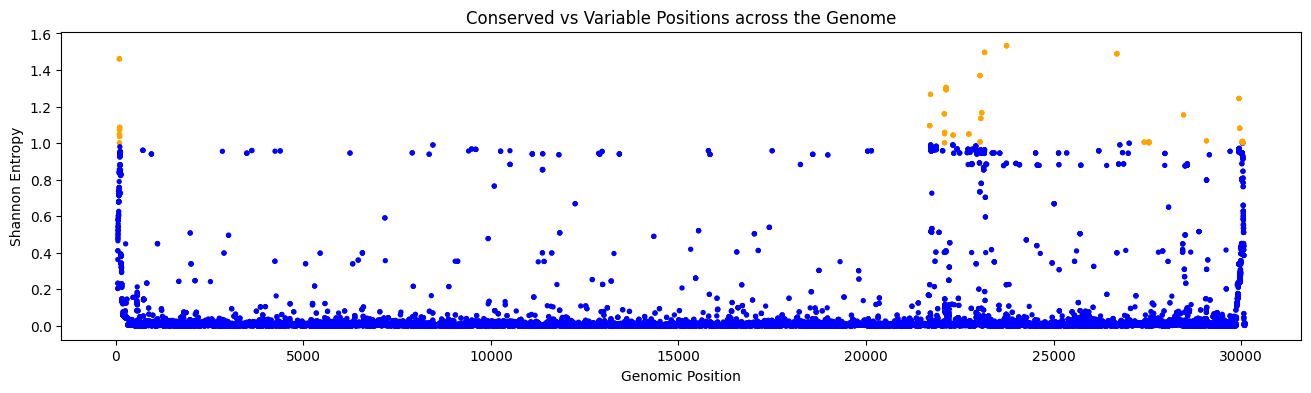

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,4))
colors = {"Conserved": "blue", "Variable": "orange"}
plt.scatter(
    data["Position"],
    data["Shannon_Entropy"],
    c=data["Entropy_Class"].map(colors),
    s=8
)
plt.xlabel("Genomic Position")
plt.ylabel("Shannon Entropy")
plt.title("Conserved vs Variable Positions across the Genome")
plt.show()

## frequent class plot

In [8]:
print(f"class counts {data.Frequency_Class.value_counts()}")

class counts Frequency_Class
Rare             24689
Common             197
Low-frequency      140
Name: count, dtype: int64


Text(0, 0.5, 'Count')

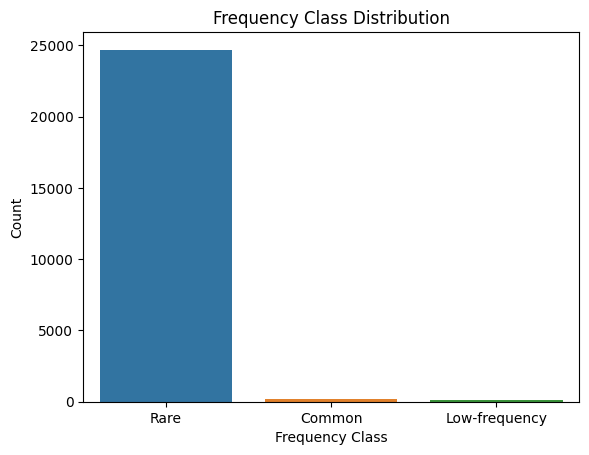

In [9]:
sns.countplot(x="Frequency_Class", data=data, hue="Frequency_Class")
plt.title("Frequency Class Distribution")
plt.xlabel("Frequency Class")
plt.ylabel("Count")

## identfiyng feature axis and target axis for our dataset

In [10]:
# المتغيرات المستقلة (features)
X = data.drop(columns=['Frequency_Class'], axis=1)
# المتغير التابع (target)
y = data["Frequency_Class"]

In [11]:
# Re-define X_train and y_train to ensure they are available
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [12]:
!pip install scikit-plot -Uq

## Create Preprocessing Pipelines

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# define the columns based on data types
numerical_features = ['Position', 'Count', 'Allele_Frequency', 'Shannon_Entropy'] # Normalization
categorical_features = ['Reference_Base', 'Sample_Base', 'Entropy_Class']

# Instantiate StandardScaler for numerical features
numerical_transformer = StandardScaler() # mean 0 sd 1 

# Instantiate OneHotEncoder for categorical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create a ColumnTransformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop', # # Drop any columns not specified in transformers
)

## Build and Train the Random Forest Pipeline


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


# Create the new Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=8,
        class_weight='balanced',
        random_state=42
    ))
])

# Train the Random Forest pipeline
rf_pipeline.fit(X_train, y_train)

print("Random Forest pipeline created and trained successfully.")

# Make predictions with the Random Forest pipeline
rf_preds = rf_pipeline.predict(X_test)

# Evaluate the Random Forest pipeline
print("\nResults of Random Forest Pipeline with ColumnTransformer:")
print("Accuracy:", round(accuracy_score(y_test, rf_preds), 3))
print(classification_report(y_test, rf_preds))

Random Forest pipeline created and trained successfully.

Results of Random Forest Pipeline with ColumnTransformer:
Accuracy: 1.0
               precision    recall  f1-score   support

       Common       0.98      1.00      0.99        49
Low-frequency       1.00      0.97      0.99        35
         Rare       1.00      1.00      1.00      6173

     accuracy                           1.00      6257
    macro avg       0.99      0.99      0.99      6257
 weighted avg       1.00      1.00      1.00      6257



## SVM Pipeline

In [18]:
from sklearn.svm import SVC

# Create the SVM pipeline
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=100, # regularization
        class_weight='balanced',
        random_state=42,
        probability=True
    ))
])

# Train the SVM pipeline
svm_pipeline.fit(X_train, y_train)

print("SVM pipeline created and trained successfully.")

# Make predictions with the SVM pipeline
svm_preds = svm_pipeline.predict(X_test)

# Evaluate the SVM pipeline
print("\nResults of SVM Pipeline with ColumnTransformer:")
print("Accuracy:", round(accuracy_score(y_test, svm_preds), 3))
print(classification_report(y_test, svm_preds))

SVM pipeline created and trained successfully.

Results of SVM Pipeline with ColumnTransformer:
Accuracy: 0.998
               precision    recall  f1-score   support

       Common       0.98      1.00      0.99        49
Low-frequency       0.78      0.91      0.84        35
         Rare       1.00      1.00      1.00      6173

     accuracy                           1.00      6257
    macro avg       0.92      0.97      0.94      6257
 weighted avg       1.00      1.00      1.00      6257



## #  تقييم إضافي باستخدام Cross-Validation

In [19]:
svm_scores = cross_val_score(svm_pipeline, X, y, cv=5)
rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# مقارنة النموذجين
results_df = pd.DataFrame({
    "Model": ["SVM", "Random Forest", "SVM (CV)", "Random Forest (CV)"],
    "Accuracy": [
        accuracy_score(y_test, svm_preds),
        accuracy_score(y_test, rf_preds), # Added Random Forest test accuracy
        svm_scores.mean(),                # Added SVM cross-validation mean accuracy
        rf_cv_scores.mean()
    ]
})

print("\n comparing models:")
print(results_df)

# حفظ النتائج في ملف CSV
results_df.to_csv("model_comparison_results_balanced.csv", index=False, encoding="utf-8-sig")
print("\n model_comparison_results_balanced.csv")


 comparing models:
                Model  Accuracy
0                 SVM  0.998082
1       Random Forest  0.999840
2            SVM (CV)  0.997643
3  Random Forest (CV)  0.999880

 model_comparison_results_balanced.csv


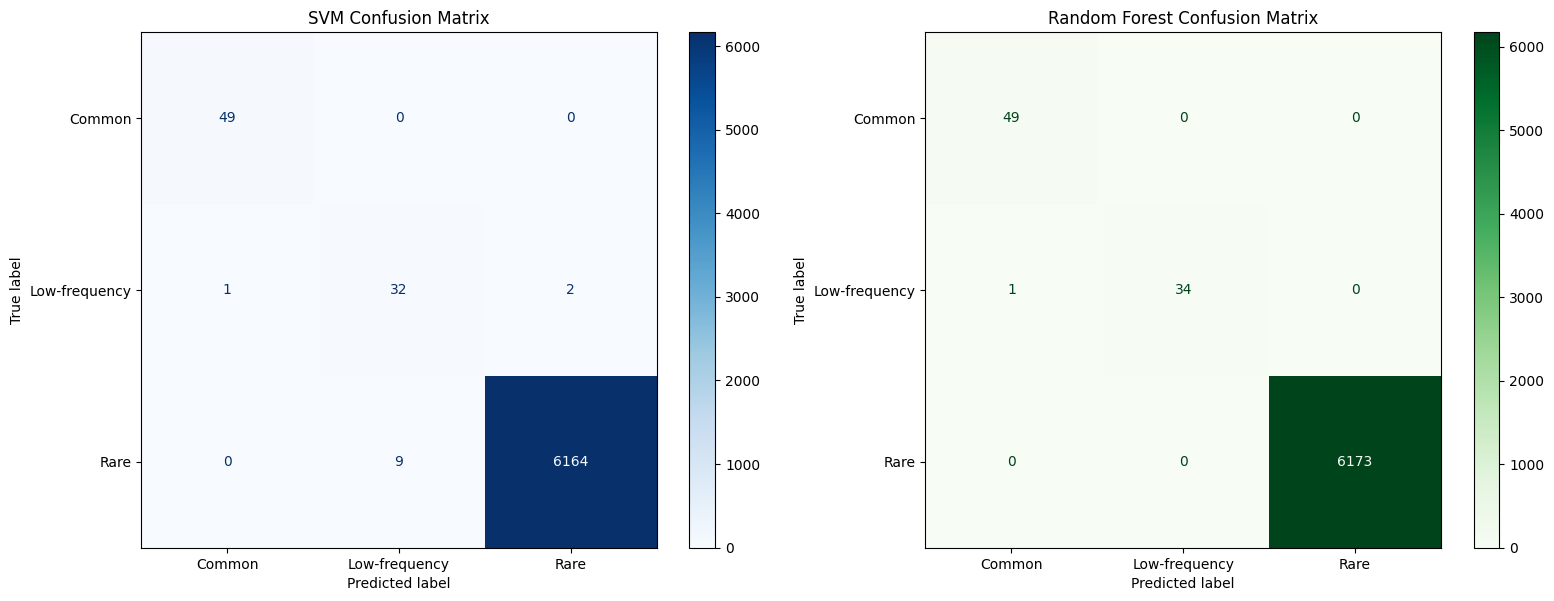

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for SVM 
cm_svm = confusion_matrix(y_test, svm_preds, labels=svm_pipeline.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_pipeline.classes_)

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_preds, labels=rf_pipeline.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_pipeline.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot SVM Confusion Matrix
disp_svm.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('SVM Confusion Matrix')

# Plot Random Forest Confusion Matrix
disp_rf.plot(ax=axes[1], cmap=plt.cm.Greens)
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder

# Calculate median for numerical features (excluding 'Allele_Frequency' and 'Shannon_Entropy')
other_numerical_features = [f for f in numerical_features if f not in ['Allele_Frequency', 'Shannon_Entropy']]
median_values = X[other_numerical_features].median().to_dict()

# Calculate mode for categorical features
mode_values = {col: X[col].mode()[0] for col in categorical_features}

#this code to  idefine xx, yy, le, cmap, colors, and class_labels

# Define min/max values for Allele_Frequency and Shannon_Entropy for the grid
x_min, x_max = X['Allele_Frequency'].min() - 0.001, X['Allele_Frequency'].max() + 0.001
y_min, y_max = X['Shannon_Entropy'].min() - 0.1, X['Shannon_Entropy'].max() + 0.1

# Create a meshgrid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Encode target variable for plotting
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_labels = le.classes_

# Define colormap for plotting
colors = plt.cm.Set1(np.linspace(0, 1, len(class_labels)))
cmap = ListedColormap(colors)

# End of the code **

# Create a DataFrame for the grid points
# The number of rows will be the product of the dimensions of xx and yy
n_grid_points = xx.size

# Initialize an empty DataFrame with the same columns as X
grid_df = pd.DataFrame(index=range(n_grid_points), columns=X.columns)

# Fill 'Allele_Frequency' and 'Shannon_Entropy' from xx and yy
grid_df['Allele_Frequency'] = xx.ravel()
grid_df['Shannon_Entropy'] = yy.ravel()

# Fill other numerical features with their median values
for col, val in median_values.items():
    grid_df[col] = val

# Fill categorical features with their mode values
for col, val in mode_values.items():
    grid_df[col] = val

# Ensure the column order is identical to X
grid_df = grid_df[X.columns]

print("Grid DataFrame (grid_df) created with appropriate feature values.")
print(grid_df.head())

Grid DataFrame (grid_df) created with appropriate feature values.
   Position Reference_Base Sample_Base  Count  Allele_Frequency  \
0   15824.5              t           t    2.0         -0.000962   
1   15824.5              t           t    2.0          0.004111   
2   15824.5              t           t    2.0          0.009185   
3   15824.5              t           t    2.0          0.014258   
4   15824.5              t           t    2.0          0.019332   

   Shannon_Entropy Entropy_Class  
0        -0.099404     Conserved  
1        -0.099404     Conserved  
2        -0.099404     Conserved  
3        -0.099404     Conserved  
4        -0.099404     Conserved  


In [22]:
svm_preds_grid = svm_pipeline.predict(grid_df)
rf_preds_grid = rf_pipeline.predict(grid_df)

svm_preds_grid_encoded = le.transform(svm_preds_grid)
rf_preds_grid_encoded = le.transform(rf_preds_grid)

print("Predictions made and encoded for both SVM and Random Forest pipelines.")

Predictions made and encoded for both SVM and Random Forest pipelines.


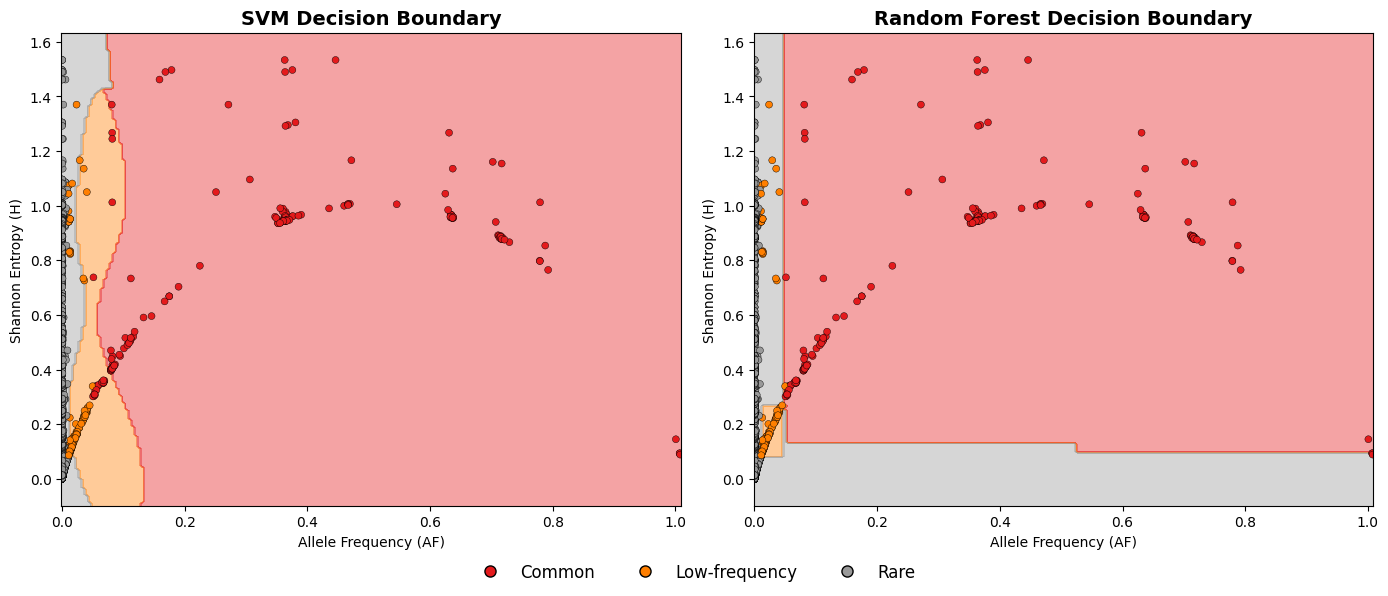


AF_H_Classification_Comparison.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SVM Plot
axes[0].contourf(xx, yy, svm_preds_grid_encoded.reshape(xx.shape), alpha=0.4, cmap=cmap)
scatter0 = axes[0].scatter(
    X["Allele_Frequency"], X["Shannon_Entropy"],
    c=y_encoded, cmap=cmap, s=25, edgecolor='k', linewidth=0.3
)
axes[0].set_title("SVM Decision Boundary", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Allele Frequency (AF)")
axes[0].set_ylabel("Shannon Entropy (H)")

# Random Forest Plot
axes[1].contourf(xx, yy, rf_preds_grid_encoded.reshape(xx.shape), alpha=0.4, cmap=cmap)
scatter1 = axes[1].scatter(
    X["Allele_Frequency"], X["Shannon_Entropy"],
    c=y_encoded, cmap=cmap, s=25, edgecolor='k', linewidth=0.3
)
axes[1].set_title("Random Forest Decision Boundary", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Allele Frequency (AF)")
axes[1].set_ylabel("Shannon Entropy (H)")

# Create a common legend for both plots
legend_labels = [plt.Line2D([0], [0], marker='o', color='w',
                            label=cls, markerfacecolor=col, markersize=8, markeredgecolor='k')
                 for cls, col in zip(class_labels, colors)]

fig.legend(handles=legend_labels, loc='lower center', ncol=3, fontsize=12, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("AF_H_Classification_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nAF_H_Classification_Comparison.png")